In [102]:
import pandas as pd
from pandarallel import pandarallel
import pyarrow
import numpy as np
import spacy
from spacy import displacy
from spacy.matcher import Matcher, PhraseMatcher
from spacy.util import filter_spans
import json
import re
import warnings
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from snownlp import SnowNLP

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# see section Aspect Based Sentiment Analysis -> Analysis -> Weighing Title and Content
EN_TITLE_WEIGHT = 7.94
EN_CONTENT_WEIGHT = 356

ALPHA = 0.05

# list generated by Gemini
relevant_eng_deps = [
    'acomp',   # Adjectival complement (e.g., "is effective")
    'advmod',  # Adverbial modifier (e.g., "highly", "completely")
    'neg',     # Negation (e.g., "not", "never")
    'dobj',    # Direct object (e.g., "cleared the infection")
    'xcomp',   # Open clausal complement (e.g., "seems to work")
    'attr'     # Attribute (e.g., "is a scam")
]
relevant_chinese_deps = [
    'acomp', 'advmod', 'neg', 'dobj', 'xcomp', 'attr', 'dep', 'aux:asp', 'amod'
]
clause_deps = ['conj', 'parataxis', 'ccomp']
anchor_pos = ['ADJ', 'VERB', 'AUX']

In [22]:
# run once
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /home/reptiman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/reptiman/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/reptiman/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
with open("scraping/scrape_keywords/medicine_flattened.json") as file:
    keywords = json.load(file)

# Aspect Based Sentiment Analysis

## spaCy
- English model: [en_core_web_sm](https://spacy.io/models/en)
- Chinese model: [zh_core_web_sm](https://spacy.io/models/zh)

In [3]:
def nlp_factory(keywords, lang = "en"):
    if lang == "en":
        nlp = spacy.load("en_core_web_sm")
    else:
        nlp = spacy.load("zh_core_web_sm")
    return nlp

In [4]:
class custom_nlp():
    def __init__(self, keywords, lang='en'):
        self.keywords = keywords
        self.lang = lang
        self.nlp = nlp_factory(keywords, lang)
    
    def find_span(self, doc, keyword):
        if self.lang == "en":
            search_str = rf"(?i)\b{re.escape(keyword)}s*\b"
        else:
            search_str = re.escape(keyword)
        spans = []
        span_map = {}
        for match in re.finditer(search_str, doc.text):
            start_char, end_char = match.span()
            span = doc.char_span(start_char, end_char, alignment_mode="expand") # align to tokens that cover the whole sequence
            spans.append(span)
            span_map[span] = keyword
        return spans, span_map
    
    def __call__(self, text):
        doc = self.nlp(text)
        self.doc = doc
        spans = []
        span_maps = {}
        for keyword in self.keywords:
            cur_spans, span_map = self.find_span(doc, keyword)
            spans.extend(cur_spans)
            span_maps.update(span_map)
        # use the longest coverage
        spans = filter_spans(spans)
        with doc.retokenize() as retokenizer:
            for span in spans:
                lemma = span_maps.get(span, None)
                if lemma is None:
                    warnings.warn(f"Span <{span}> does not match any keyword.")
                retokenizer.merge(span, attrs={"LEMMA": lemma})
        return doc


In [5]:
nlp_dict = {
    "en": custom_nlp(keywords['en'], "en"),
    "zh": custom_nlp(keywords['cn'], "zh")
}

### QC

In [103]:
displacy.render(nlp_dict['en'](f"I used Mometasone furoate this morning"))

In [104]:
displacy.render(nlp_dict['en'](f"I used Danpifen Ruangao this morning"))

In [105]:
displacy.render(nlp_dict['en'](f"I used Danpifen this morning"))

In [106]:
nlp_dict['en'](f"I used Mometasone furoate this morning")[2].lemma_

'Mometasone furoate'

In [107]:
nlp_dict['en'](f"I used Mometasone furoate this morning")[2].dep_

'dobj'

In [108]:
displacy.render(nlp_dict['en']("Lianhua Qingwen Jiaonang was so bitter. I wanted to throw up. Yuck!!!"))

In [109]:
displacy.render(nlp_dict['en']("I forgot to put on my steroid creams before I left home for school this morning"))

In [110]:
displacy.render(nlp_dict['zh']("二型糖尿病是由于胰岛素抵抗导致的"))

In [111]:
displacy.render(nlp_dict['zh']("连花清瘟胶囊是治疗新冠的良药"))

In [112]:
%%timeit
nlp_dict['en']("Lianhua Qingwen Jiaonang was so bitter")

4.81 ms ± 368 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [113]:
%%timeit
nlp_dict['zh']("连花清瘟胶囊是治疗新冠的良药")

4.65 ms ± 692 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Sentence Parser

In [6]:
def prune_sentence_for_aspect(text, aspect, nlp):
    doc = nlp(text)
    target_tokens = []
    for token in doc:
        if token.lemma_ == aspect:
            target_tokens.append(token)

    pruned_sents = []
    for target_token in target_tokens:
        relevant_tokens = set()
        # add all modifiers of the aspect
        for sub_token in target_token.subtree:
            relevant_tokens.add(sub_token)

        # find the action word for the aspect
        anchor = target_token
        while anchor.head != anchor and anchor.pos_ not in anchor_pos:
            anchor = anchor.head
        relevant_tokens.add(anchor)

        # add all modifiers of the action anchor
        for child in anchor.children:
            if child.dep_ in (relevant_eng_deps if nlp.lang=='en' else relevant_chinese_deps):
                for sub_token in child.subtree:
                    relevant_tokens.add(sub_token)
        
        if nlp.lang == 'zh':
            # Grab result clauses that occur after the action anchor
            # dependents or siblings
            head_anchor = anchor
            for i in range(2):
                for child in head_anchor.children:
                    if child.dep_ in clause_deps and child.i > anchor.i:
                        for sub_token in child.subtree:
                            relevant_tokens.add(sub_token)
                if anchor.dep_ in clause_deps:
                    head_anchor = anchor.head
                else:
                    break

        # reconstruct the sentence
        sorted_tokens = sorted(list(relevant_tokens), key=lambda token: token.i)
        if nlp.lang == "en":
            pruned_sent = " ".join([token.text for token in sorted_tokens])
        else:
            pruned_sent = "".join([token.text for token in sorted_tokens])
        pruned_sents.append(pruned_sent)
        
    return pruned_sents

### QC

In [115]:
displacy.render(nlp_dict['en']('It was much more reliable than the Danpifen Ruangao prescribed by my TCM doctor.'))

In [146]:
text_1 = "The hospital waiting room was an absolute nightmare, but the topical steroids completely cleared my severe inflammations. It was much more reliable than the Danpifen Ruangao prescribed by my TCM doctor."
aspect_1 = "Danpifen Ruangao"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['en']))

text_2 = "To be honest, the Paeonol cream was not very effective for my back, but it was good for my knees."
aspect_2 = "Paeonol Cream"
print(prune_sentence_for_aspect(text_2, aspect_2, nlp_dict['en']))

['much more reliable the Danpifen Ruangao prescribed by my TCM doctor']
['the Paeonol cream was not very effective for my back']


In [145]:
text_2 = "To be honest, the Paeonol cream was not very effective for my back, but the doctors offering it were so sweet."
aspect_2 = "Paeonol Cream"
print(prune_sentence_for_aspect(text_2, aspect_2, nlp_dict['en']))

['the Paeonol cream was not very effective for my back']


In [140]:
displacy.render(nlp_dict['en']('To be honest, the Paeonol cream was not very effective for my back, but the doctors offering it were so sweet.'))

In [119]:
displacy.render(nlp_dict['zh']('我复方黄柏液都擦了一个多月了，一点用也没有'))

In [194]:
displacy.render(nlp_dict['zh']('发烧了吃什么中药，吃布洛芬，见效快。'))

In [199]:
displacy.render(nlp_dict['zh']('我去医院，医生就开了瓶复方黄柏液，态度差得不行'))

In [207]:
text_1 = "我复方黄柏液都擦了一个多月了，一点用也没有"
aspect_1 = "复方黄柏液"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['zh']))

text_2 = "发烧了吃什么中药，吃布洛芬，见效快。"
aspect_2 = "布洛芬"
print(prune_sentence_for_aspect(text_2, aspect_2, nlp_dict['zh']))

['我复方黄柏液都擦了一个多月一点用也没有']
['吃布洛芬见效快']


In [208]:
text_1 = "我复方黄柏液都擦了一个多月了，对我的湿疹有点用，但是还是不能完全治好"
aspect_1 = "复方黄柏液"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['zh']))

['我复方黄柏液都擦了一个多月，对我的湿疹有点用但是还是不能完全治好']


In [209]:
text_1 = "我去医院，医生就开了瓶复方黄柏液，态度差得不行"
aspect_1 = "复方黄柏液"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['zh']))

['就开了瓶复方黄柏液态度差得不行']


In [210]:
text_1 = "The doctors just prescribed me a steroid cream and were so rude to me"
aspect_1 = "Steroid cream"
print(prune_sentence_for_aspect(text_1, aspect_1, nlp_dict['en']))

['just prescribed a steroid cream']


## Analysis

In [7]:
med_df = pd.read_csv("corpus/source_and_cleanup_metadata.csv")
med_df.head(2)

,id,ups,note_id,downs,search_keyword,poster,created_year,created_utc,shared_count,source,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
0,34344,37,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,0.0,Tresiba,2e65009b7023d6202cf0322ea037e3f9dccbad95d3d21a...,2025,1761778198,NaN,reddit,...,Insulin,diabetes,ebm,False,en,0.972991,en,0.831891,True,1.0
1,15129,1,d54273d76a9e58747c68f71e4416741a424e96fe835df5...,NaN,泰诺,ee3fb8546089cd65768e97fd7e37c69d9c34a25cae634d...,2026,1774688385,0.0,weibo,...,Acetaminophen,flu,ebm,False,zh,0.989413,NaN,NaN,True,1.0


In [8]:
med_df = med_df[['id', 'note_id', 'medicine_name', 'title_language', 'content_language']]
med_df.head(2)

,id,note_id,medicine_name,title_language,content_language
0,34344,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,Insulin,en,en
1,15129,d54273d76a9e58747c68f71e4416741a424e96fe835df5...,泰诺,NaN,zh


In [14]:
def parse_by_entry(note_id, medicine_name, title_lang, content_lang):
    note = pd.read_parquet(
        "corpus/cleaned/posts_by_noteid.parquet",
        filters=[('note_id', '==', note_id)]
    )
    if note.shape[0] != 1:
        warnings.warn(f"Matched {note.shape[0]} posts: note_id {note_id}")
    # remember we only looked at content for language identification when it was not null
    # assume title is in the same language as content -- this should be true most if not all of the times
    if title_lang != 'zh' and title_lang != 'en':
        title_lang = content_lang
    title_parsed = []
    content_parsed = []
    title = note['title'].iloc[0]
    if title == title: # not null
        title_parsed = prune_sentence_for_aspect(
            str(title),
            medicine_name,
            nlp_dict[title_lang]
        )
    content = note['content'].iloc[0]
    if content == content:
        content_parsed = prune_sentence_for_aspect(
            str(content),
            medicine_name,
            nlp_dict[content_lang]
        )
    return title_parsed, content_parsed

In [24]:
def parse_by_entry_store(series):
    title_parsed, content_parsed = parse_by_entry(
        series['note_id'], series['medicine_name'], series['title_language'], series['content_language']
    )
    return pd.Series({
        'title_parsed': title_parsed, 
        'content_parsed': content_parsed
    })
pandarallel.initialize(progress_bar=True)
med_df[['title_parsed', 'content_parsed']] = med_df.parallel_apply(parse_by_entry_store, axis=1)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [25]:
med_df.to_parquet('corpus/absa/parsed_cleaned_posts.parquet')

In [3]:
parsed_df = pd.read_parquet('corpus/absa/parsed_cleaned_posts.parquet')

### Weighing Title and Content

In [ ]:
parsed_df['content_parsed'].apply(lambda x: len(x)>0).sum()

np.int64(32797)

In [18]:
en_df = parsed_df.query("content_language == 'en' | (content_language != content_language & title_language == 'en')")
en_df.head(2)

,id,note_id,medicine_name,title_language,content_language,title_parsed,content_parsed
0,34344,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,Insulin,en,en,[],"[n't sound any insulin I take, also see anothe..."
2,32408,943fd948016cb72ed1a224d4080501103e3888a5f95ec4...,Oseltamivir,en,en,[],[Oseltamivir be a good one to get hold of thou...


In [20]:
en_notes = pd.read_parquet(
    "corpus/cleaned/posts_by_noteid.parquet",
    filters = [('note_id', 'in', en_df.note_id)]
)

In [26]:
en_notes['title_len'] = en_notes['title'].apply(
    lambda x: len([token for token in word_tokenize(x) if token.isalnum()]) if x==x else 0
)
en_notes['content_len'] = en_notes['content'].apply(
    lambda x: len([token for token in word_tokenize(x) if token.isalnum()]) if x==x else 0
)

In [27]:
en_notes['title_len'].mean(), en_notes['content_len'].mean()

(np.float64(7.943505405816963), np.float64(355.5315973808436))

### English

In [39]:
def vader_sentiment_analyzer(series):
    content_scores = []
    title_scores = []
    if series['content_language'] == 'en':
        sia = SentimentIntensityAnalyzer()
        for sent in series['content_parsed']:
            content_scores.append(sia.polarity_scores(sent)['compound'])
    for sent in series['title_parsed']:
        title_scores.append(sia.polarity_scores(sent)['compound'])
    agg = [pd.NA, pd.NA]
    if len(content_scores)>0:
        agg[0] = np.mean(content_scores)
    if len(title_scores)>0:
        agg[1] = np.mean(title_scores)
    return pd.Series({
        "content_scores": agg[0],
        "title_scores": agg[1]
    })

In [40]:
en_df = parsed_df.query("content_language == 'en' | (content_language != content_language & title_language == 'en')").copy()

In [41]:
pandarallel.initialize(progress_bar=True)
en_df[['content_scores', 'title_scores']] = en_df.parallel_apply(
    vader_sentiment_analyzer, axis=1
)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [50]:
def summarize_score(series):
    ts = series['title_scores']
    cs = series['content_scores']
    if (not pd.isna(ts)) and (not pd.isna(cs)):
        return (ts * EN_TITLE_WEIGHT + cs * EN_CONTENT_WEIGHT) / (EN_TITLE_WEIGHT + EN_CONTENT_WEIGHT)
    if not pd.isna(cs):
        return cs
    return ts
en_df['summary_sentiment_score'] = en_df.apply(
    summarize_score, axis=1
)
en_df

,id,note_id,medicine_name,title_language,content_language,title_parsed,content_parsed,content_scores,title_scores,summary_sentiment_score
0,34344,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,Insulin,en,en,[],"[n't sound any insulin I take, also see anothe...",0.0,<NA>,0.0
2,32408,943fd948016cb72ed1a224d4080501103e3888a5f95ec4...,Oseltamivir,en,en,[],[Oseltamivir be a good one to get hold of thou...,0.3944,<NA>,0.3944
3,33964,674e3930475a01a73805fcbce1dfe63c369bdfdd995027...,Insulin,en,en,[],"[need 3 - 4 times more insulin, bring my blood...",0.0,<NA>,0.0
8,34460,727d7be375ff17501d45ffca234ebcbddf2bb026fc9dc5...,Insulin,en,en,[Insulin Profiles],"[select the insulin, use Lyumjev my standard i...",0.0,0.0,0.0
10,32415,6aeb66c59475d0c9dd06e307445e2d319d3caf384ebb6a...,Oseltamivir,en,en,[],"[put me Oseltamivir , which is supposed to slo...",-0.3818,<NA>,-0.3818
...,...,...,...,...,...,...,...,...,...,...
38231,39772,4507d9e355f3d12beef4aa951785d9e6397d1831ed8c0e...,Motrin,en,en,[],[doing Motrin and Tylenol],0.0,<NA>,0.0
38238,35139,d58fcd5a5afce02f0c48549224c002b6ffdd8118c30d68...,Calamine,en,en,[],[Calamine imparts some aroma ) \n\n],0.0,<NA>,0.0
38244,39797,6d38fbd02ac5580fce807d99b4f40b2f3aa037b31d44a1...,Motrin,en,en,[],"[came Motrin then back to 100.7, gave some mor...",0.0,<NA>,0.0
38257,34432,bc012e3acdd3512b85dbad7eeff2ef979bd943fbbc2cb7...,Insulin,en,en,[insulin resistance],[needing a little bit more insulin but nothing...,0.18035,0.0,0.176415


In [51]:
en_df[['id', 'summary_sentiment_score']].to_csv("corpus/en_absa_scores.csv", index=False)

### Chinese

In [ ]:
s = SnowNLP('布洛芬我都吃了三天了，一点用也没有')
print(s.words)
s.sentiments

['布洛芬', '我', '都', '吃', '了', '三', '天', '了', '，', '一点', '用', '也', '没有']


0.24735279188881154

In [64]:
cn_df = parsed_df.query("content_language == 'zh'")
# recall that weibo posts do not provide a title
cn_df = cn_df.drop(columns = ['title_language', 'title_parsed'])
cn_df

,id,note_id,medicine_name,content_language,content_parsed
1,15129,d54273d76a9e58747c68f71e4416741a424e96fe835df5...,泰诺,zh,[于是狂吃vc泰诺姜汁蜂蜜水撑过了第一天SSV大粉今天LakeLouise小粉和最难的bow...
4,28628,faced4d97987e61c9cc8775f5d7964379686649e590151...,黄连,zh,[]
5,18700,388337c1cbe5e35f1b7626c4906069701a04f34b7814a1...,布洛芬,zh,"[布洛芬很着急为您服务我看话题里有人在建议用神药安乃近，不懂不要紧但不要乱建议真的会害人的,..."
6,22356,6ca14b8d12332f3032865d0f57c99fb3447e27fe85bcb5...,激素药膏,zh,[]
7,10938,ccc289c17147854cd6ff2bb1efe4ef8a28673761634d7f...,可的松,zh,[可的松]
...,...,...,...,...,...
38254,20332,8154b619dbcc55a291ea7b5ed7c30e552ad3fd5f00a486...,胰岛素,zh,"[若使用注射类药物如胰岛素针剂, 无论胰岛素是否开封, 胰岛素放, 胰岛素不可放入行李箱托运..."
38255,28209,fd5b9c70e819871fcfe0ba9c922f50f0df3c9101e42328...,黄连,zh,[毒片黄连上清丸、三黄片、蒲地蓝等]
38256,4679,88b83453d4dcbc41d0b5db88045f0994e9ee3c0a09cdcd...,必理通,zh,[普通感冒发热药物（如对乙酰氨基酚）有条件的可选原研药必理通或泰诺林]
38259,28118,a2e0ed11f49b17f54bade043edcd94c68d92a84ebe7c75...,黄连,zh,[继续清热消肿经济又好用适合配合调理体质 5.单味快攻方（简单应急鲜蒲公英捣烂外敷清热解毒...


In [65]:
pandarallel.initialize(progress_bar=True)
cn_df['summary_sentiment_score'] = cn_df['content_parsed'].parallel_apply(
    lambda sents: np.mean([SnowNLP(sent).sentiments for sent in sents]) if len(sents) > 0 else pd.NA
)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [67]:
cn_df[['id', 'summary_sentiment_score']].to_csv("corpus/cn_absa_scores.csv", index=False)

## Result

### Merge sentiment scores

In [8]:
labels = ['Negative', 'Neutral', 'Positive']

In [9]:
en_sent = pd.read_csv("corpus/en_absa_scores.csv").dropna(subset='summary_sentiment_score')
vadar_bins = [-1.0, -0.05, 0.05, 1.0]
en_sent['sentiment'] = pd.cut(
    en_sent['summary_sentiment_score'],
    bins=vadar_bins,
    labels=labels,
    include_lowest=True
)
# normalize to [0, 1]
en_sent['score'] = (en_sent['summary_sentiment_score']+1)/2

In [10]:
cn_sent = pd.read_csv("corpus/cn_absa_scores.csv").dropna(subset='summary_sentiment_score')
snow_bins = [0.0, 0.33, 0.66, 1.0]
cn_sent['sentiment'] = pd.cut(
    cn_sent['summary_sentiment_score'],
    bins=snow_bins,
    labels=labels,
    include_lowest=True
)
cn_sent['score'] = cn_sent['summary_sentiment_score']

In [11]:
sent = pd.concat([en_sent, cn_sent])[['id', 'score', 'sentiment']]
sent

,id,score,sentiment
0,34344,0.500000,Neutral
1,32408,0.697200,Positive
2,33964,0.500000,Neutral
3,34460,0.500000,Neutral
4,32415,0.309100,Negative
...,...,...,...
27610,331,0.998472,Positive
27611,20332,0.407582,Neutral
27612,28209,0.463010,Neutral
27613,4679,0.453985,Neutral


In [12]:
metadata = pd.read_csv("corpus/source_and_cleanup_metadata.csv")

In [13]:
sent_df = pd.merge(sent, metadata, on='id', how='left')
sent_df.head(2)

,id,score,sentiment,ups,note_id,downs,search_keyword,poster,created_year,created_utc,...,medicine_en_uname,medicine_category,medicine_type,condition_mentioned,content_language,content_language_confidence,title_language,title_language_confidence,related,related_proba
0,34344,0.5000,Neutral,37,65b0412ef73902ad657db42b9f0ffb1898c14fa021935f...,0.0,Tresiba,2e65009b7023d6202cf0322ea037e3f9dccbad95d3d21a...,2025,1761778198,...,Insulin,diabetes,ebm,False,en,0.972991,en,0.831891,True,1.0
1,32408,0.6972,Positive,15,943fd948016cb72ed1a224d4080501103e3888a5f95ec4...,0.0,Oseltamivir,22876da7290a0fe5197848ae711f9a61baf1c027b2dcdf...,2024,1711797193,...,Tamiflu,flu,ebm,True,en,0.969591,en,0.922214,True,1.0


In [23]:
sent_df.to_csv("corpus/metadata_with_absa_scores.csv", index=False)

### Raw Scores

In [14]:
sent_df[['medicine_type', 'medicine_en_uname']]

,medicine_type,medicine_en_uname
0,ebm,Insulin
1,ebm,Tamiflu
2,ebm,Insulin
3,ebm,Insulin
4,ebm,Tamiflu
...,...,...
33194,tcm,Liuwei Dihuang Wan
33195,ebm,Insulin
33196,tcm,Coptis
33197,ebm,Acetaminophen


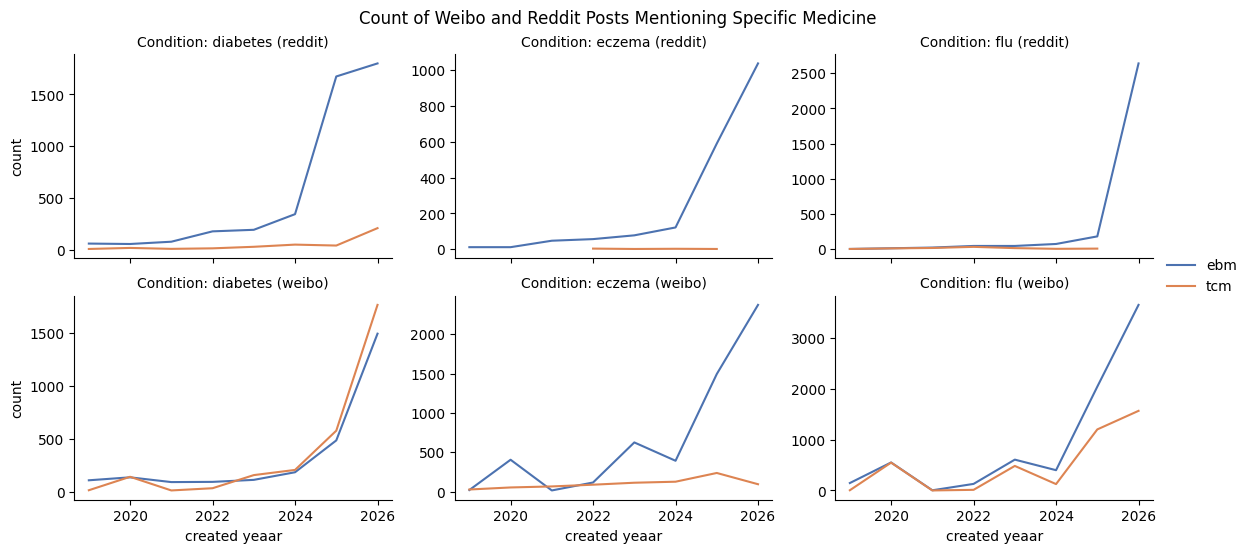

In [15]:
agg_df = sent_df.groupby(by=['source', 'medicine_category', 'medicine_type', 'created_year'])['id'].agg('count').to_frame().reset_index()
agg_df = agg_df.rename(columns={'id': 'count'})
g = sns.FacetGrid(agg_df, row = "source", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
med_types = agg_df["medicine_type"].unique().tolist()
med_types.sort()
g.map_dataframe(sns.lineplot, x="created_year", y='count', hue="medicine_type", hue_order=med_types, palette="deep")
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Count of Weibo and Reddit Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.set_xlabels("created yeaar")
g.add_legend()
g.savefig("results/absa_count.png", dpi=310)

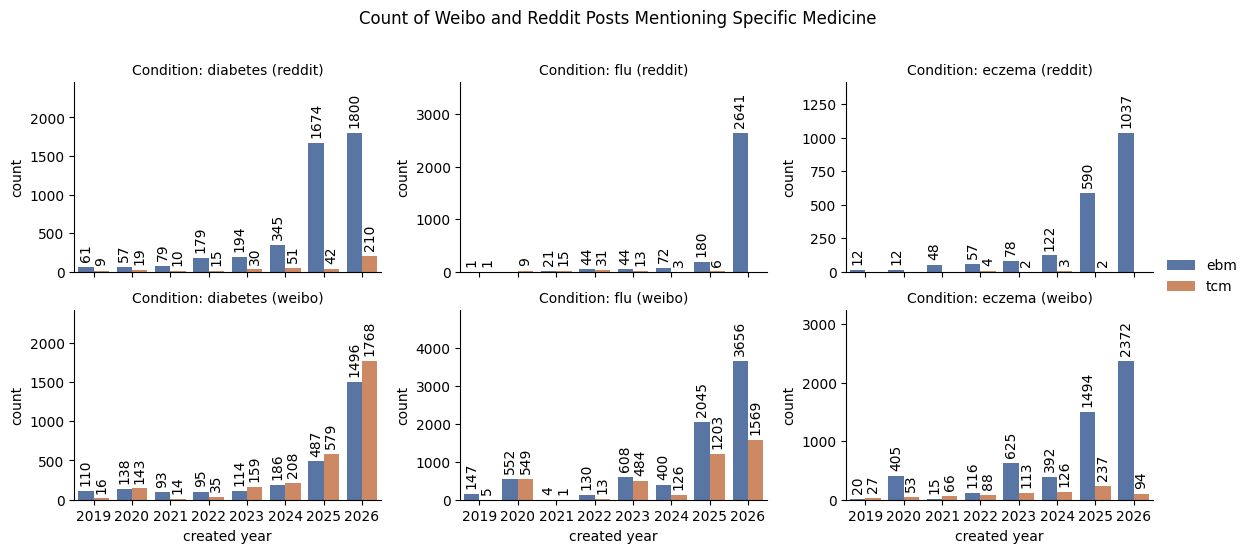

In [16]:
g = sns.FacetGrid(sent_df, row = "source", col = "medicine_category", height=2.8, aspect=1.4, sharey=False)
def custom_countplot(**kwargs):
    ax = sns.countplot(**kwargs)
    for container in ax.containers:
        ax.bar_label(container, rotation=90, padding=4)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.3)
med_types = sent_df["medicine_type"].unique().tolist()
med_types.sort()
g.map_dataframe(custom_countplot, x="created_year", hue="medicine_type", hue_order=med_types, palette="deep", dodge=True)
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Count of Weibo and Reddit Posts Mentioning Specific Medicine")
g.set_titles("Condition: {col_name} ({row_name})")
g.set_xlabels("created year")
g.add_legend()
g.savefig("results/absa_count_labeled.png", dpi=310)

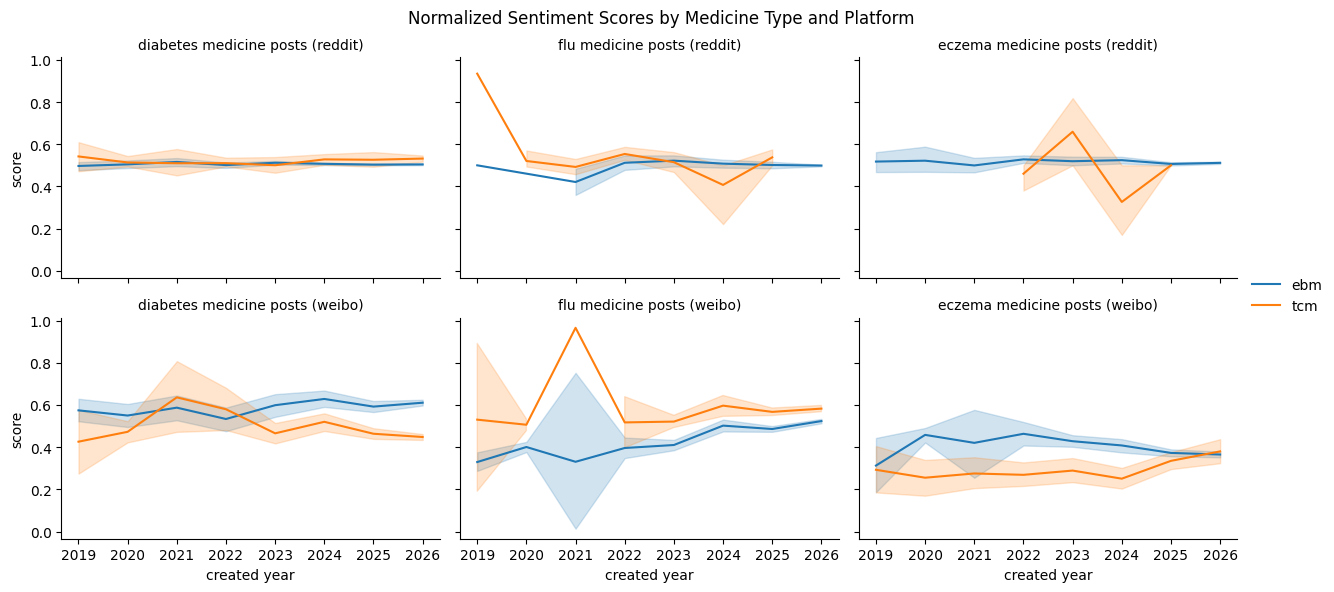

In [17]:
g = sns.FacetGrid(sent_df, row='source', col='medicine_category', height=3, aspect=1.4)
med_types = sent_df["medicine_type"].unique().tolist()
med_types.sort()
g.map_dataframe(sns.lineplot, x='created_year', y='score', hue='medicine_type', hue_order=med_types)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("created year")
g.fig.suptitle("Normalized Sentiment Scores by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_scores.png", dpi=310)

### Categorize

In [50]:
def categorize_df(df, groupby_cols):
    pos_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Positive')).to_frame().reset_index().rename(columns = {"sentiment": "positive_count"})
    neg_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Negative')).to_frame().reset_index().rename(columns = {"sentiment": "negative_count"})
    count_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg('count').to_frame().reset_index().rename(columns = {"sentiment": "count"})
    category_df = pd.merge(pos_df, neg_df, on=groupby_cols, how='inner')
    category_df = pd.merge(category_df, count_df, on=groupby_cols, how='inner')
    return category_df

In [51]:
groupby_cols = ['source', 'medicine_category', 'medicine_type', 'created_year']
category_df = categorize_df(sent_df, groupby_cols)
category_df

,source,medicine_category,medicine_type,created_year,positive_count,negative_count,count
0,reddit,diabetes,ebm,2019,9,5,61
1,reddit,diabetes,ebm,2020,5,3,57
2,reddit,diabetes,ebm,2021,17,8,79
3,reddit,diabetes,ebm,2022,22,13,179
4,reddit,diabetes,ebm,2023,24,16,194
...,...,...,...,...,...,...,...
85,weibo,flu,tcm,2022,3,2,13
86,weibo,flu,tcm,2023,191,155,484
87,weibo,flu,tcm,2024,59,25,126
88,weibo,flu,tcm,2025,545,329,1203


In [31]:
category_df['positive'] = category_df['positive_count'] / category_df['count'] * 100
category_df['negative'] = category_df['negative_count'] / category_df['count'] * 100

In [33]:
category_df_long = category_df.melt(
    id_vars = groupby_cols,
    value_vars = ['positive', 'negative'],
    value_name = 'percent',
    var_name = 'sentiment'
)
category_df_long

,source,medicine_category,medicine_type,created_year,sentiment,percent
0,reddit,diabetes,ebm,2019,positive,14.754098
1,reddit,diabetes,ebm,2020,positive,8.771930
2,reddit,diabetes,ebm,2021,positive,21.518987
3,reddit,diabetes,ebm,2022,positive,12.290503
4,reddit,diabetes,ebm,2023,positive,12.371134
...,...,...,...,...,...,...
175,weibo,flu,tcm,2022,negative,15.384615
176,weibo,flu,tcm,2023,negative,32.024793
177,weibo,flu,tcm,2024,negative,19.841270
178,weibo,flu,tcm,2025,negative,27.348296


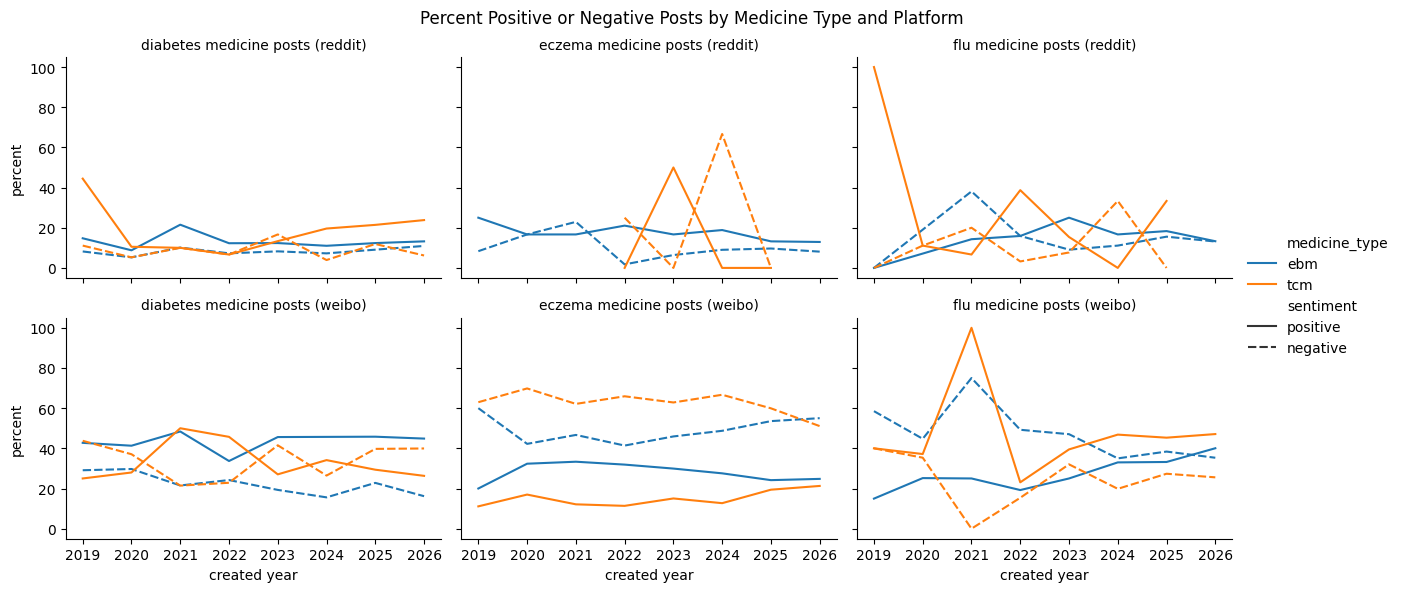

In [44]:
g = sns.FacetGrid(category_df_long, row='source', col='medicine_category', height=3, aspect=1.4)
med_types = category_df_long["medicine_type"].unique().tolist()
med_types.sort()
sent_types = ['positive', 'negative']
g.map_dataframe(
    sns.lineplot, x='created_year', y='percent',
    hue='medicine_type', hue_order=med_types,
    style='sentiment', style_order=sent_types
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("created year")
g.fig.suptitle("Percent Positive or Negative Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_categories.png", dpi=310)

In [60]:
COVID_CUTOFF = 2023
sent_df = pd.read_csv("corpus/metadata_with_absa_scores.csv")

/tmp/ipykernel_31432/821565045.py:2: DtypeWarning: Columns (0: title_language) have mixed types. Specify dtype option on import or set low_memory=False.
  sent_df = pd.read_csv("corpus/metadata_with_absa_scores.csv")


In [61]:
sent_df['period'] = (sent_df['created_year'] > COVID_CUTOFF).apply(lambda x: "post-covid" if x else "covid")

In [62]:
covid_sent_df = categorize_df(sent_df, groupby_cols = ['source', 'medicine_category', 'medicine_type', 'period'])
covid_sent_df

,source,medicine_category,medicine_type,period,positive_count,negative_count,count
0,reddit,diabetes,ebm,covid,77,45,570
1,reddit,diabetes,ebm,post-covid,483,374,3819
2,reddit,diabetes,tcm,covid,12,9,83
3,reddit,diabetes,tcm,post-covid,69,20,303
4,reddit,eczema,ebm,covid,38,20,207
5,reddit,eczema,ebm,post-covid,235,152,1749
6,reddit,eczema,tcm,covid,1,1,6
7,reddit,eczema,tcm,post-covid,0,2,5
8,reddit,flu,ebm,covid,21,19,110
9,reddit,flu,ebm,post-covid,396,383,2893


In [63]:
covid_sent_df['positive'] = covid_sent_df['positive_count'] / covid_sent_df['count'] * 100
covid_sent_df['negative'] = covid_sent_df['negative_count'] / covid_sent_df['count'] * 100

In [64]:
covid_sent_df_long = covid_sent_df.melt(
    id_vars = ['source', 'medicine_category', 'medicine_type', 'period'],
    value_vars = ['positive', 'negative'],
    value_name = 'percent',
    var_name = 'sentiment'
)
covid_sent_df_long.head(2)

,source,medicine_category,medicine_type,period,sentiment,percent
0,reddit,diabetes,ebm,covid,positive,13.508772
1,reddit,diabetes,ebm,post-covid,positive,12.647290


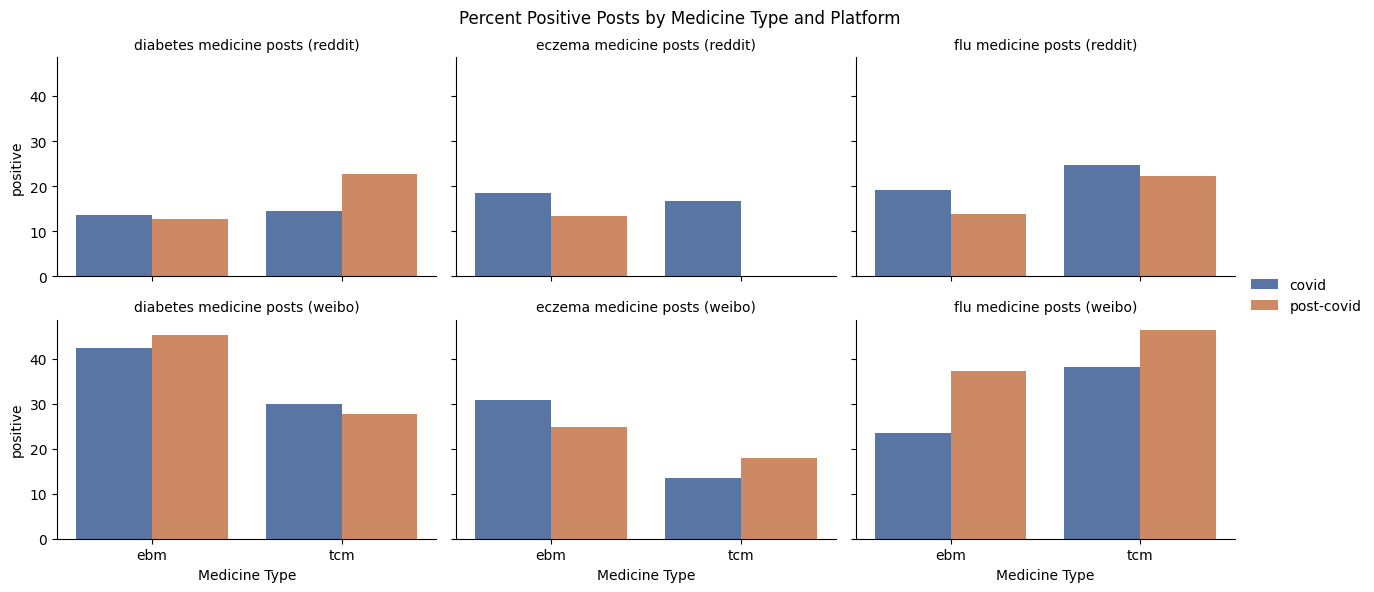

In [67]:
g = sns.FacetGrid(covid_sent_df, row='source', col='medicine_category', height=3, aspect=1.4)
g.map_dataframe(
    sns.barplot, x='medicine_type', y='positive',
    hue='period', hue_order=["covid", "post-covid"],
    palette='deep'
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("Medicine Type")
g.fig.suptitle("Percent Positive Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_covid_positives.png", dpi=310)

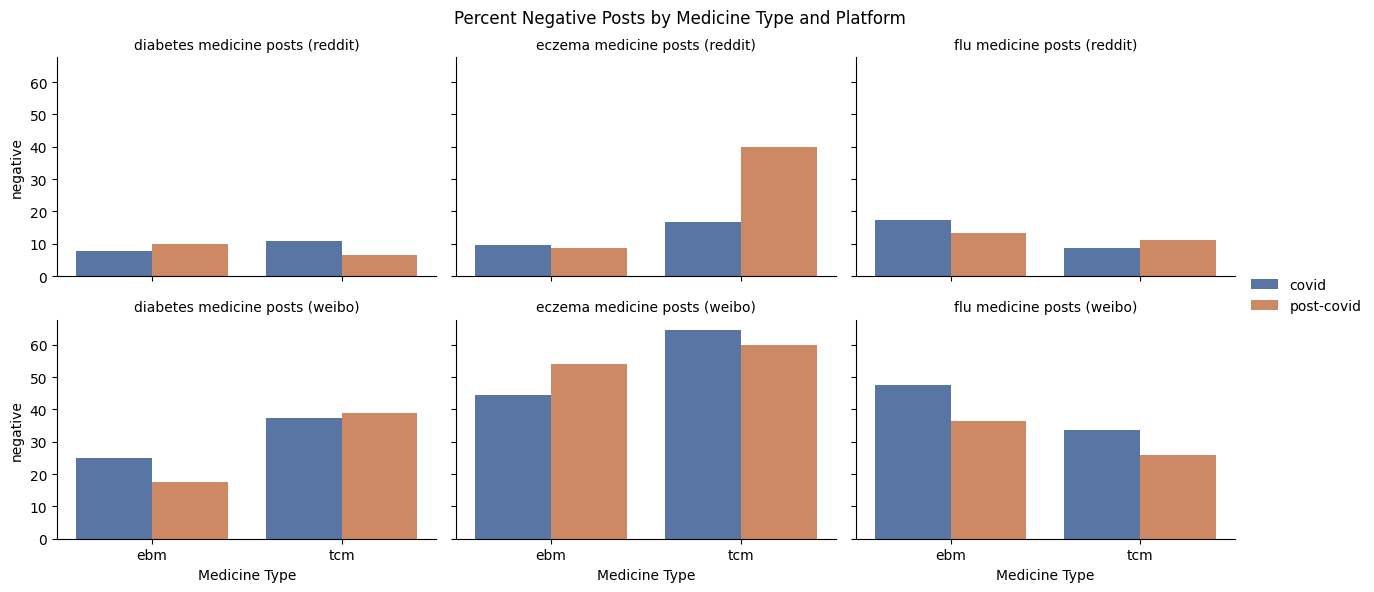

In [68]:
g = sns.FacetGrid(covid_sent_df, row='source', col='medicine_category', height=3, aspect=1.4)
g.map_dataframe(
    sns.barplot, x='medicine_type', y='negative',
    hue='period', hue_order=["covid", "post-covid"],
    palette='deep'
)
g.set_titles(template="{col_name} medicine posts ({row_name})")
g.set_xlabels("Medicine Type")
g.fig.suptitle("Percent Negative Posts by Medicine Type and Platform")
g.fig.tight_layout()
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.savefig("results/absa_covid_negatives.png", dpi=310)

### Is there a difference between COVID and post-COVID opinions on the same types of medicines?

In [71]:
covid_sent_df.head(2)

,source,medicine_category,medicine_type,period,positive_count,negative_count,count,positive,negative
0,reddit,diabetes,ebm,covid,77,45,570,13.508772,7.894737
1,reddit,diabetes,ebm,post-covid,483,374,3819,12.647290,9.793140


In [96]:
conds = covid_sent_df[['source', 'medicine_category', 'medicine_type']].drop_duplicates()
pvals = []
zstats = []
for i, series in conds.iterrows():
    source, med_cat, med_type = series
    df = covid_sent_df.query("source==@source and medicine_category==@med_cat and medicine_type==@med_type")
    successes = (df[df['period']=='covid']['positive_count'].iloc[0], df[df['period']=='post-covid']['positive_count'].iloc[0])
    counts = (df[df['period']=='covid']['count'].iloc[0], df[df['period']=='post-covid']['count'].iloc[0])
    stat, pval = proportions_ztest(successes, counts, alternative="two-sided")
    zstats.append(stat)
    pvals.append(pval)

positive z values: covid > post-covid

In [97]:
conds['pval_two_sided'] = pvals
conds['z_stat_two_sided'] = zstats
conds['sig_two_sided'] = conds['pval_two_sided'] < (ALPHA/conds.shape[0])
conds

,source,medicine_category,medicine_type,pval_two_sided,z_stat_two_sided,sig_two_sided
0,reddit,diabetes,ebm,5.652584e-01,0.575049,False
2,reddit,diabetes,tcm,9.932333e-02,-1.648143,False
4,reddit,eczema,ebm,5.335488e-02,1.932037,False
6,reddit,eczema,tcm,3.383517e-01,0.957427,False
8,reddit,flu,ebm,1.077619e-01,1.608335,False
10,reddit,flu,tcm,8.738439e-01,0.158778,False
12,weibo,diabetes,ebm,2.426806e-01,-1.168313,False
14,weibo,diabetes,tcm,3.499872e-01,0.934614,False
16,weibo,eczema,ebm,3.310099e-05,4.151011,True
18,weibo,eczema,tcm,9.236118e-02,-1.683072,False


In [98]:
conds.to_csv("results/absa_longitudinal_trust_change_stats.csv", index=False)

### Is there a difference between post-COVID opinions on EBM vs. TCM?

In [99]:
post_covid = covid_sent_df[covid_sent_df['period']=="post-covid"]
conds = post_covid[['source', 'medicine_category']].drop_duplicates()
pvals = []
zstats = []
for i, series in conds.iterrows():
    source, med_cat = series
    df = post_covid.query("source==@source and medicine_category==@med_cat")
    successes = (df[df['medicine_type']=='tcm']['positive_count'].iloc[0], df[df['medicine_type']=='ebm']['positive_count'].iloc[0])
    counts = (df[df['medicine_type']=='tcm']['count'].iloc[0], df[df['medicine_type']=='ebm']['count'].iloc[0])
    stat, pval = proportions_ztest(successes, counts, alternative="two-sided")
    zstats.append(stat)
    pvals.append(pval)

Positive z values: tcm > ebm

In [100]:
conds['pval_two_sided'] = pvals
conds['z_stat_two_sided'] = zstats
conds['sig_two_sided'] = conds['pval_two_sided'] < (ALPHA/conds.shape[0])
conds

,source,medicine_category,pval_two_sided,z_stat_two_sided,sig_two_sided
1,reddit,diabetes,6.316497e-07,4.981280,True
5,reddit,eczema,3.784452e-01,-0.880765,False
9,reddit,flu,4.574301e-01,0.743085,False
13,weibo,diabetes,6.137928e-36,-12.515553,True
17,weibo,eczema,1.091913e-03,-3.265707,True
21,weibo,flu,2.735419e-16,8.184454,True


In [101]:
conds.to_csv("results/absa_tcm_vs_ebm_postcovid_stats.csv", index=False)

### Is there a difference between post-COVID opinion polarization on Weibo vs. Reddit?

#### Is the ratio of (positive TCM / positive EBM) different between platforms?

In [122]:
post_covid = covid_sent_df[covid_sent_df['period']=="post-covid"]
conds = post_covid[['medicine_category']].drop_duplicates()
pvals = []
print(f"Significance level = {ALPHA / conds.shape[0]}")
for i, series in conds.iterrows():
    med_cat = series['medicine_category']
    df = post_covid.query("medicine_category==@med_cat")
    weibo = df[df['source'] == 'weibo']
    reddit = df[df['source'] == 'reddit']
    contingency_table = [
        [weibo[weibo['medicine_type']=='tcm']['positive_count'].iloc[0], weibo[weibo['medicine_type']=='ebm']['positive_count'].iloc[0]], # Weibo Positive Posts
        [reddit[reddit['medicine_type']=='tcm']['positive_count'].iloc[0], reddit[reddit['medicine_type']=='ebm']['positive_count'].iloc[0]]  # Reddit Positive Posts
    ]
    chi2, pval, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"<======== {med_cat} | p-value: {np.round(pval, 4)} | sig = {pval < ALPHA / conds.shape[0]} ========>")
    print(pd.DataFrame(contingency_table, index=['weibo', 'reddit'], columns=['tcm', 'ebm']))
    print(pd.DataFrame(np.round(expected).astype(int), index=['weibo', 'reddit'], columns=['tcm', 'ebm']))
    pvals.append(pval)

Significance level = 0.016666666666666666
<======== diabetes | p-value: 0.0 | sig = True ========>
        tcm  ebm
weibo   706  979
reddit   69  483
        tcm   ebm
weibo   584  1101
reddit  191   361
<======== eczema | p-value: 0.0 | sig = True ========>
        tcm   ebm
weibo    82  1057
reddit    0   235
        tcm   ebm
weibo    68  1071
reddit   14   221
<======== flu | p-value: 0.0 | sig = True ========>
         tcm   ebm
weibo   1343  2275
reddit     2   396
         tcm   ebm
weibo   1212  2406
reddit   133   265


#### Is the difference in post-COVID trust in TCM vs. EBM different by platform?

In [125]:
COVID_CUTOFF = 2023
sent_df = pd.read_csv("corpus/metadata_with_absa_scores.csv")
sent_df['period'] = (sent_df['created_year'] > COVID_CUTOFF).apply(lambda x: "post-covid" if x else "covid")
post_covid_sent = sent_df[sent_df['period'] == 'post-covid']
post_covid_sent = post_covid_sent[['id', 'sentiment', 'source', 'medicine_category', 'medicine_type']]
post_covid_sent.head(2)

/tmp/ipykernel_31432/365548883.py:2: DtypeWarning: Columns (0: title_language) have mixed types. Specify dtype option on import or set low_memory=False.
  sent_df = pd.read_csv("corpus/metadata_with_absa_scores.csv")


,id,sentiment,source,medicine_category,medicine_type
0,34344,Neutral,reddit,diabetes,ebm
1,32408,Positive,reddit,flu,ebm


In [128]:
def calc_proportions(df, groupby_cols):
    pos_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Positive')).to_frame().reset_index().rename(columns = {"sentiment": "positive_count"})
    neg_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg(lambda x: sum(x=='Negative')).to_frame().reset_index().rename(columns = {"sentiment": "negative_count"})
    count_df = df.groupby(
        by=groupby_cols
    )['sentiment'].agg('count').to_frame().reset_index().rename(columns = {"sentiment": "count"})
    category_df = pd.merge(pos_df, neg_df, on=groupby_cols, how='inner')
    category_df = pd.merge(category_df, count_df, on=groupby_cols, how='inner')
    category_df['pos_p'] = category_df['positive_count'] / category_df['count']
    category_df['neg_p'] = category_df['negative_count'] / category_df['count']
    return category_df

In [155]:
def calc_pos_p_diff(metadata):
    groupby_cols = ['source', 'medicine_category', 'medicine_type']
    df = calc_proportions(metadata, groupby_cols=groupby_cols)
    df = df.pivot_table(index=['source', 'medicine_category'], columns='medicine_type', values='pos_p').reset_index()
    df['tcm-ebm'] = df['tcm'] - df['ebm']
    return df[['source', 'medicine_category', 'tcm-ebm']]

In [195]:
def calc_did(metadata):
    df = calc_pos_p_diff(metadata)
    df = df.pivot_table(index='medicine_category', columns='source', values='tcm-ebm').reset_index()
    df['weibo-reddit_tcm-ebm'] = df['weibo'] - df['reddit']
    return df

In [196]:
emp_df = calc_did(post_covid_sent)
emp_df

source,medicine_category,reddit,weibo,weibo-reddit_tcm-ebm
0,diabetes,0.101250,-0.175039,-0.276289
1,eczema,-0.134362,-0.068808,0.065555
2,flu,0.085340,0.090533,0.005193


In [199]:
n_permutes = 999
rng = np.random.default_rng(42)
emp_df = calc_did(post_covid_sent)
for i in tqdm(range(n_permutes)):
    permuted_md = post_covid_sent.copy()
    permuted_md['source'] = post_covid_sent['source'].sample(
        n=len(post_covid_sent['source']), replace=False, random_state = rng
    ).to_list()
    null_df = calc_did(permuted_md)[['medicine_category', 'weibo-reddit_tcm-ebm']]
    null_df = null_df.rename(columns = {'weibo-reddit_tcm-ebm': f'null_{i}'})
    emp_df = pd.merge(emp_df, null_df, on='medicine_category')

  0%|          | 0/999 [00:00<?, ?it/s]

In [204]:
p_vals = []
null_means = []
null_stds = []
for i, series in emp_df.iterrows():
    emp_dp = series['weibo-reddit_tcm-ebm']
    null_dps = series[[f"null_{i}" for i in range(n_permutes)]]
    n_ge = sum(abs(null_dps) >= abs(emp_dp))
    p_val = (n_ge+1)/(n_permutes+1)
    null_mean = null_dps.mean()
    null_std = null_dps.std()
    p_vals.append(p_val)
    null_means.append(null_mean)
    null_stds.append(null_std)

In [205]:
dp_df = emp_df[['medicine_category', 'weibo-reddit_tcm-ebm']].copy()
dp_df['p_val'] = p_vals
dp_df['null_mean'] = null_means
dp_df['null_std'] = null_stds
dp_df

source,medicine_category,weibo-reddit_tcm-ebm,p_val,null_mean,null_std
0,diabetes,-0.276289,0.001,0.000506,0.021978
1,eczema,0.065555,0.120,0.000145,0.041050
2,flu,0.005193,0.819,-0.000011,0.022109


In [206]:
dp_df.to_csv("results/absa_did_by_med_category.csv", index=False)